# 1. Importing Libraries

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os


# 2. Loading and Merging Datasets

In [5]:
import pandas as pd
import os

# Define the dataset paths
dataset_paths = [
    "/kaggle/input/ids-intrusion-csv/02-14-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-15-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-16-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-20-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-22-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-23-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-28-2018.csv",
    "/kaggle/input/ids-intrusion-csv/03-01-2018.csv",
    "/kaggle/input/ids-intrusion-csv/03-02-2018.csv"
]

# Loop through each dataset path and print the matrix size (rows, columns) of each file
for file_path in dataset_paths:
    if os.path.exists(file_path):
        # Load the dataset into pandas dataframe with low_memory=False to avoid dtype warning
        df = pd.read_csv(file_path, low_memory=False)
        
        # Get the shape (number of rows and columns)
        rows, cols = df.shape
        
        print(f"File: {file_path}, Matrix Size: {rows} rows x {cols} columns")
    else:
        print(f"File {file_path} does not exist.")

File: /kaggle/input/ids-intrusion-csv/02-14-2018.csv, Matrix Size: 1048575 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/02-15-2018.csv, Matrix Size: 1048575 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/02-16-2018.csv, Matrix Size: 1048575 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/02-20-2018.csv, Matrix Size: 7948748 rows x 84 columns
File: /kaggle/input/ids-intrusion-csv/02-22-2018.csv, Matrix Size: 1048575 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/02-23-2018.csv, Matrix Size: 1048575 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/02-28-2018.csv, Matrix Size: 613104 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/03-01-2018.csv, Matrix Size: 331125 rows x 80 columns
File: /kaggle/input/ids-intrusion-csv/03-02-2018.csv, Matrix Size: 1048575 rows x 80 columns


In [6]:
import pandas as pd
# Dropinng the "/kaggle/input/ids-intrusion-csv/02-20-2018.csv" dataset due to the mismatching of the coloumns
# Define the dataset paths
dataset_paths = [
    "/kaggle/input/ids-intrusion-csv/02-14-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-15-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-16-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-22-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-23-2018.csv",
    "/kaggle/input/ids-intrusion-csv/02-28-2018.csv",
    "/kaggle/input/ids-intrusion-csv/03-01-2018.csv",
    "/kaggle/input/ids-intrusion-csv/03-02-2018.csv"
]

# Initialize an empty list to store dataframes
dataframes = []

# Desired number of rows for the merged dataset
desired_rows = 1048575

# First, read the first dataset to get a starting shape
merged_df = pd.read_csv(dataset_paths[0])

# Calculate the number of rows remaining to be added
remaining_rows = desired_rows - merged_df.shape[0]

# Load the remaining datasets
for file in dataset_paths[1:]:
    # Read the dataset
    df = pd.read_csv(file)
    
    # Calculate how many rows to take from this dataset
    rows_to_take = min(remaining_rows, df.shape[0])
    
    # Add the selected rows to the dataframes list
    dataframes.append(df.head(rows_to_take))
    
    # Update the remaining rows to be added
    remaining_rows -= rows_to_take
    
    # If we've reached the desired number of rows, stop
    if remaining_rows <= 0:
        break

# Add the first dataset to the list
dataframes.insert(0, merged_df)

# Concatenate all the selected rows into one large dataframe
final_df = pd.concat(dataframes, ignore_index=True)

# If necessary, crop the dataframe to exactly 1,048,575 rows
final_df = final_df.head(desired_rows)

# Save the merged dataset to a file
final_df.to_csv('/kaggle/working/merged_dataset_1048575.csv', index=False)

# Display the first few rows of the merged dataset
final_df.head()

# Ensure the dataset has exactly 1,048,575 rows
print(f"Final dataset shape: {final_df.shape}")

# Display the columns of the final dataset
final_df.columns


Final dataset shape: (1048575, 80)


Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

# 3. Analyzing the Data (Correlations, Missing Values)

Missing Values in Each Column:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64
Matrix Size of the Final Cleaned Dataset: 1046298 rows x 81 columns
Columns in the Final Dataset:
Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


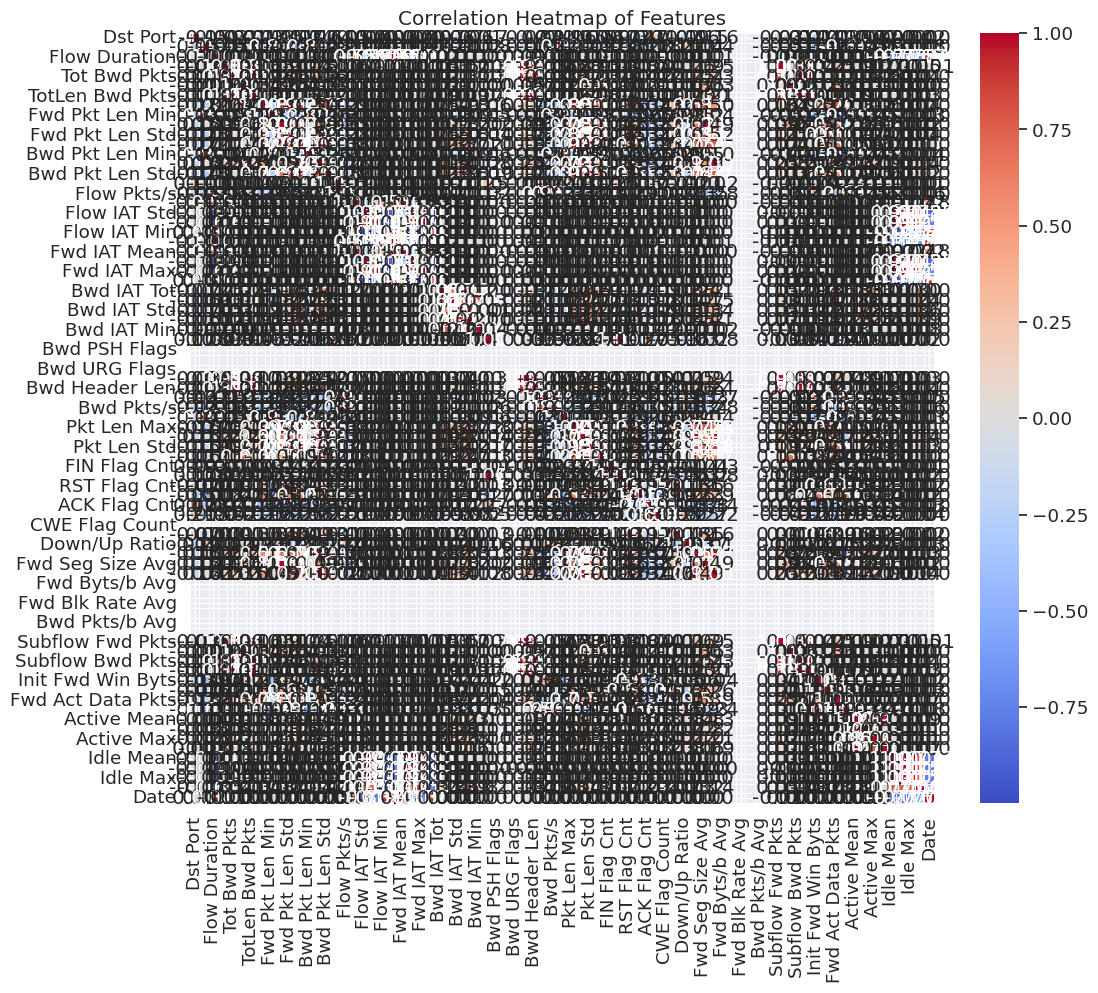

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the final merged dataset
final_df = pd.read_csv('/kaggle/working/merged_dataset_1048575.csv')

# Checking for missing values in the dataset
missing_values = final_df.isnull().sum()

# Display missing values count
print("Missing Values in Each Column:")
print(missing_values)

# Drop rows with missing values (if any)
final_df.dropna(inplace=True)

# Convert the 'Timestamp' column to datetime format
final_df['Timestamp'] = pd.to_datetime(final_df['Timestamp'], errors='coerce', dayfirst=True)

# Create 'Date' and 'Time' columns from the 'Timestamp' column
final_df['Date'] = final_df['Timestamp'].dt.date
final_df['Time'] = final_df['Timestamp'].dt.time

# Convert 'Date' to numerical format (number of days since the epoch)
final_df['Date'] = (pd.to_datetime(final_df['Date']) - pd.Timestamp("1970-01-01")).dt.days

# Convert 'Time' to numerical format (total seconds since midnight)
final_df['Time'] = final_df['Timestamp'].dt.hour * 3600 + final_df['Timestamp'].dt.minute * 60 + final_df['Timestamp'].dt.second

# Drop the 'Timestamp' column
final_df.drop('Timestamp', axis=1, inplace=True)

# Rearrange the columns to make 'Label' the last column
columns = [col for col in final_df.columns if col != 'Label']
final_df = final_df[columns + ['Label']]

# Save the updated dataset with 'Label' as the last column
final_df.to_csv('/kaggle/working/Last_dataset_with_numeric_date_time.csv', index=False)

# Display the matrix size (rows x columns) of the final cleaned dataset
matrix_size = final_df.shape
print(f"Matrix Size of the Final Cleaned Dataset: {matrix_size[0]} rows x {matrix_size[1]} columns")

# Print all the columns in the final cleaned dataset
print("Columns in the Final Dataset:")
print(final_df.columns)

# Select only numeric columns for correlation calculation
numeric_df = final_df.select_dtypes(include=['float64', 'int64'])

# Check for NaN or infinity values in numeric data and replace them with NaN
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values in numeric columns (for correlation calculation)
numeric_df.dropna(inplace=True)

# Checking for correlations between features
correlation_matrix = numeric_df.corr()

# Plotting the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Features")
plt.show()


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the final cleaned dataset
final_df = pd.read_csv('/kaggle/working/Last_dataset_with_numeric_date_time.csv')

# Display the first 10 rows and data types of the dataset (10x81)
print("First 10 rows of the dataset:")
print(final_df.head(10))

# Print the data types of each column
print("\nData types for each column:")
print(final_df.dtypes)

# Display the values in the 'Label' column
print("\nValues in the 'Label' column:")
print(final_df['Label'].unique())

First 10 rows of the dataset:
   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0         0         0      112641719             3             0   
1         0         0      112641466             3             0   
2         0         0      112638623             3             0   
3        22         6        6453966            15            10   
4        22         6        8804066            14            11   
5        22         6        6989341            16            12   
6         0         0      112640480             3             0   
7         0         0      112641244             3             0   
8        80         6         476513             5             3   
9        80         6         475048             5             3   

   TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
0                0                0                0                0   
1                0                0                0                0   
2 

Missing Values in Each Column:
Dst Port         0
Protocol         0
Flow Duration    0
Tot Fwd Pkts     0
Tot Bwd Pkts     0
                ..
Idle Max         0
Idle Min         0
Date             0
Time             0
Label            0
Length: 81, dtype: int64
Missing Values in Features:
Dst Port         0
Protocol         0
Flow Duration    0
Tot Fwd Pkts     0
Tot Bwd Pkts     0
                ..
Idle Std         0
Idle Max         0
Idle Min         0
Date             0
Time             0
Length: 80, dtype: int64
Training Data Shape: (835800, 80)
Test Data Shape: (156713, 80)
Validation Data Shape: (52238, 80)


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


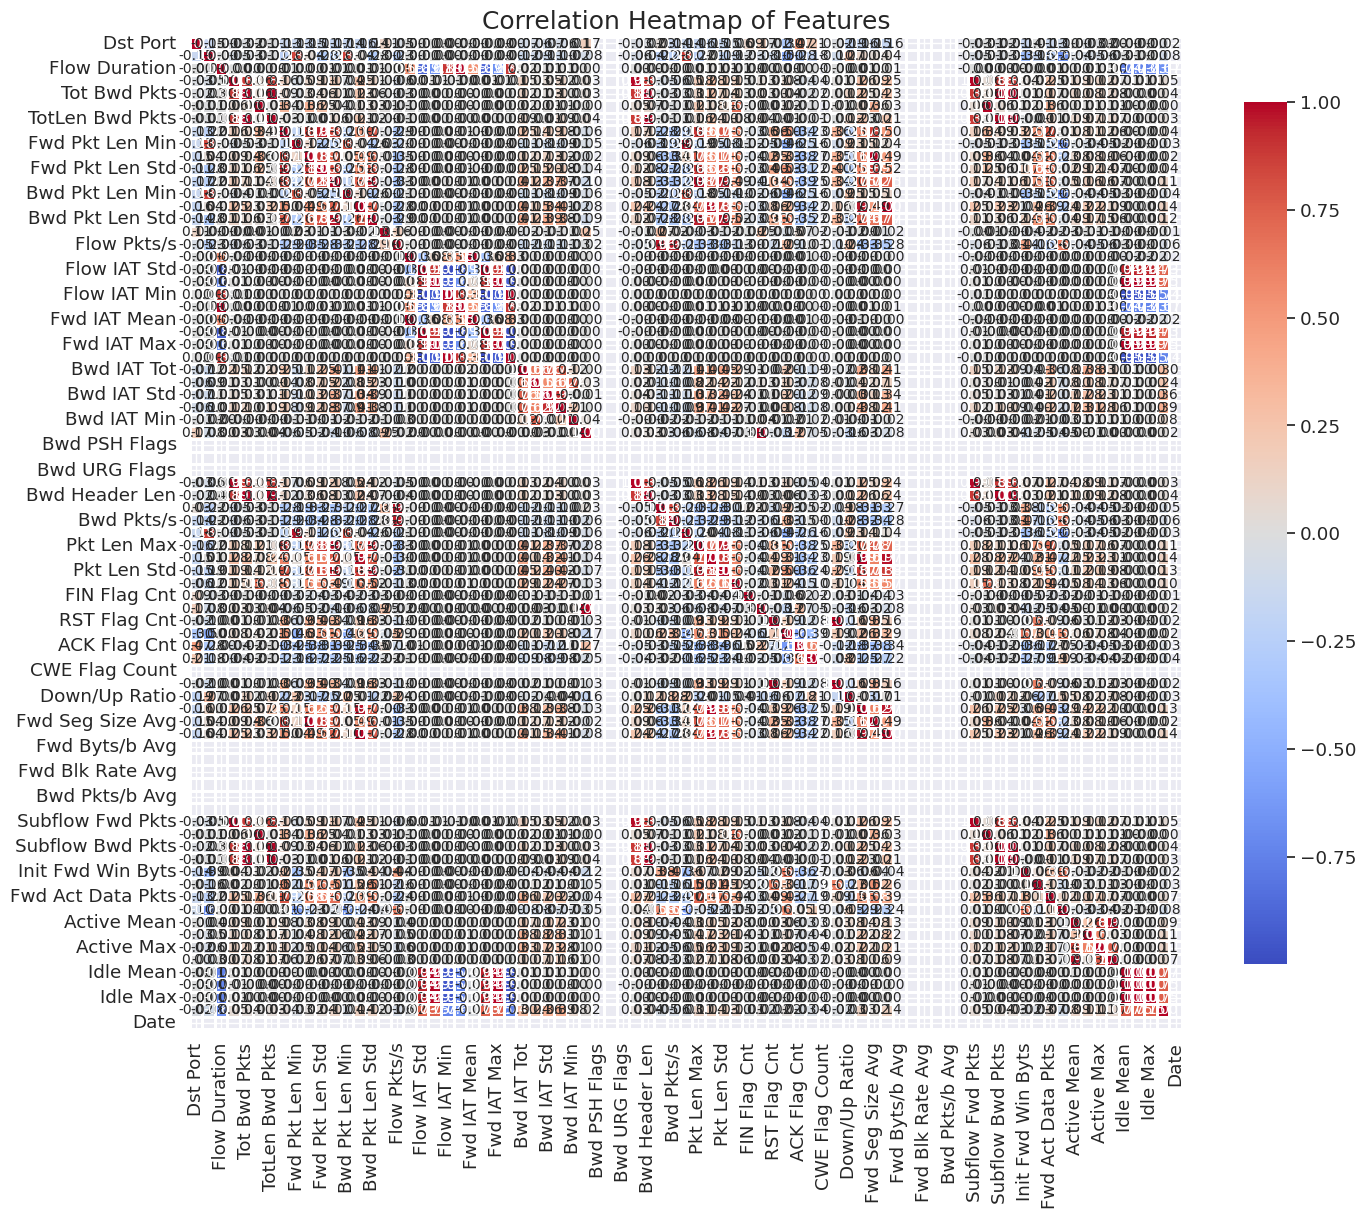


Data types for each column:
Dst Port          int64
Protocol          int64
Flow Duration     int64
Tot Fwd Pkts      int64
Tot Bwd Pkts      int64
                  ...  
Idle Max          int64
Idle Min          int64
Date              int64
Time              int64
Label            object
Length: 81, dtype: object

Final dataset saved to '/kaggle/working/Last_dataset.csv'


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load the final cleaned dataset
final_df = pd.read_csv('/kaggle/working/Last_dataset_with_numeric_date_time.csv')

# Checking for missing values in the dataset
missing_values = final_df.isnull().sum()
print(f"Missing Values in Each Column:\n{missing_values}")

# Replace infinity values with NaN
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values (if any)
final_df.dropna(inplace=True)

# Convert 'Date' to numerical format (number of days since the epoch)
if 'Date' in final_df.columns:
    final_df['Date'] = (pd.to_datetime(final_df['Date']) - pd.Timestamp("1970-01-01")).dt.days
else:
    print("No 'Date' column found in the dataset. Please check the column name.")

# Convert 'Time' to numerical format (total seconds since midnight)
def convert_time(value):
    try:
        # Cast to integer if necessary and then convert time in seconds to proper time format
        return pd.to_datetime(int(value), unit='s').strftime('%H:%M:%S')
    except ValueError:
        # If the conversion fails, return the original value (likely a time string)
        return value

# Convert 'Time' column to total seconds since midnight (if 'Time' is in HH:MM:SS format)
final_df['Time'] = final_df['Time'].apply(lambda x: convert_time(x))

# Convert 'Time' to total seconds since midnight (if 'Time' is in HH:MM:SS format)
final_df['Time'] = pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.hour * 3600 + \
                    pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.minute * 60 + \
                    pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.second

# Dropping non-numeric columns ('Label') from features
X = final_df.drop(['Label'], axis=1)  # Features
y = final_df['Label']  # Target variable

# Checking for missing values in the features (X)
missing_values = X.isnull().sum()
print(f"Missing Values in Features:\n{missing_values}")

# Drop rows with missing values in features
X.dropna(inplace=True)
y = y[X.index]  # Ensure the target (y) matches the remaining rows in X

# Split the data into training (80%), testing (15%), and validation (5%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42)  # 80% train, 20% temp (test + validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 15% test, 5% validation

# Standardizing the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# Display the shape of the datasets after scaling
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Test Data Shape: {X_test_scaled.shape}")
print(f"Validation Data Shape: {X_val_scaled.shape}")

# Plotting the correlation heatmap with improved readability
plt.figure(figsize=(16, 14))  # Increase figure size for better clarity
sns.set(font_scale=1.2)  # Increase font size for annotations and labels

# Select only numeric columns for correlation calculation
numeric_df = final_df.select_dtypes(include=['float64', 'int64'])

# Check for NaN or infinity values in numeric data and replace them with NaN
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values in numeric columns (for correlation calculation)
numeric_df.dropna(inplace=True)

# Checking for correlations between features
correlation_matrix = numeric_df.corr()

# Plotting the heatmap with enhanced settings
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.8, 
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 10}, square=True)

# Title for the heatmap
plt.title("Correlation Heatmap of Features", fontsize=18)

# Show the plot
plt.show()

# Print the data types of each column
print("\nData types for each column:")
print(final_df.dtypes)

# Save the final cleaned dataset with numeric 'Date' and 'Time' columns
final_df.to_csv('/kaggle/working/Last_dataset.csv', index=False)
print("\nFinal dataset saved to '/kaggle/working/Last_dataset.csv'")


# 4. Preparing the Data for Machine Learning

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np


# Define a function for training and evaluating models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Model Training
    model.fit(X_train, y_train)

    # Model Prediction
    y_pred = model.predict(X_test)

    # Model Evaluation: Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')

    # Print Model Evaluation Results
    print(f"\n{model.__class__.__name__} Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf_model, X_train_scaled, y_train, X_test_scaled, y_test)



RandomForestClassifier Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # Using SVC with probability=True instead of LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import joblib

# Load the final cleaned dataset
final_df = pd.read_csv('/kaggle/working/Last_dataset.csv')

# Checking for missing values in the dataset
missing_values = final_df.isnull().sum()
print(f"Missing Values in Each Column:\n{missing_values}")

# Replace infinity values with NaN
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values (if any)
final_df.dropna(inplace=True)

# Convert 'Date' to numerical format (number of days since the epoch)
if 'Date' in final_df.columns:
    final_df['Date'] = (pd.to_datetime(final_df['Date']) - pd.Timestamp("1970-01-01")).dt.days
else:
    print("No 'Date' column found in the dataset. Please check the column name.")

# Convert 'Time' to numerical format (total seconds since midnight)
def convert_time(value):
    try:
        # Cast to integer if necessary and then convert time in seconds to proper time format
        return pd.to_datetime(int(value), unit='s').strftime('%H:%M:%S')
    except ValueError:
        # If the conversion fails, return the original value (likely a time string)
        return value

# Convert 'Time' column to total seconds since midnight (if 'Time' is in HH:MM:SS format)
final_df['Time'] = final_df['Time'].apply(lambda x: convert_time(x))

# Convert 'Time' to total seconds since midnight (if 'Time' is in HH:MM:SS format)
final_df['Time'] = pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.hour * 3600 + \
                    pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.minute * 60 + \
                    pd.to_datetime(final_df['Time'], format='%H:%M:%S').dt.second

# Dropping non-numeric columns ('Label') from features
X = final_df.drop(['Label'], axis=1)  # Features
y = final_df['Label']  # Target variable

# Checking for missing values in the features (X)
missing_values = X.isnull().sum()
print(f"Missing Values in Features:\n{missing_values}")

# Drop rows with missing values in features
X.dropna(inplace=True)
y = y[X.index]  # Ensure the target (y) matches the remaining rows in X

# Split the data into training (80%), testing (15%), and validation (5%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42)  # 80% train, 20% temp (test + validation)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 15% test, 5% validation

# Standardizing the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

# Display the shape of the datasets after scaling
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Test Data Shape: {X_test_scaled.shape}")
print(f"Validation Data Shape: {X_val_scaled.shape}")

# Define a function for training and evaluating models
def evaluate_model(model, X_train, y_train, X_test, y_test, evaluate_roc_auc=False):
    print(f"Training {model.__class__.__name__}...")
    # Model Training
    model.fit(X_train, y_train)

    # Model Prediction
    y_pred = model.predict(X_test)

    # Model Evaluation: Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Initialize ROC-AUC as None, will compute if the model supports predict_proba()
    roc_auc = None
    if evaluate_roc_auc:
        try:
            roc_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
        except AttributeError:
            print(f"{model.__class__.__name__} does not support predict_proba(), skipping ROC-AUC calculation.")

    # Print Model Evaluation Results
    print(f"\n{model.__class__.__name__} Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    if roc_auc is not None:
        print(f"ROC-AUC: {roc_auc:.4f}")
    return accuracy

# 1. Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_accuracy = evaluate_model(rf_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

# 2. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_accuracy = evaluate_model(dt_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

# 3. Support Vector Machine (SVM) (Using SVC with probability=True for faster training)
svm_model = SVC(probability=True, random_state=42)  # Changed to SVC with probability=True
svm_accuracy = evaluate_model(svm_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

# 4. Neural Network (MLPClassifier)
mlp_model = MLPClassifier(random_state=42)
mlp_accuracy = evaluate_model(mlp_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

# Ensemble Modeling (Voting Classifier)
# Soft Voting
ensemble_soft_model = VotingClassifier(
    estimators=[('rf', rf_model), ('dt', dt_model), ('svm', svm_model), ('mlp', mlp_model)],
    voting='soft'  # Soft voting uses predicted probabilities
)

# Hard Voting
ensemble_hard_model = VotingClassifier(
    estimators=[('rf', rf_model), ('dt', dt_model), ('svm', svm_model), ('mlp', mlp_model)],
    voting='hard'  # Hard voting uses majority class prediction
)

# Evaluate Ensemble Models
print("\nEvaluating Soft Voting Ensemble Model...")
ensemble_soft_accuracy = evaluate_model(ensemble_soft_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

print("\nEvaluating Hard Voting Ensemble Model...")
ensemble_hard_accuracy = evaluate_model(ensemble_hard_model, X_train_scaled, y_train, X_test_scaled, y_test, evaluate_roc_auc=True)

# Ranking models by accuracy
model_accuracies = {
    'Random Forest': rf_accuracy,
    'Decision Tree': dt_accuracy,
    'SVM': svm_accuracy,
    'MLP': mlp_accuracy,
    'Ensemble (Soft Voting)': ensemble_soft_accuracy,
    'Ensemble (Hard Voting)': ensemble_hard_accuracy
}

# Sorting models by accuracy
sorted_models = sorted(model_accuracies.items(), key=lambda x: x[1], reverse=True)
print("\nModel Ranking by Accuracy:")
for i, (model, accuracy) in enumerate(sorted_models, 1):
    print(f"{i}. {model}: {accuracy:.4f}")

# Save the best model (Ensemble Model with higher accuracy) and its scaler
best_model = ensemble_soft_model if ensemble_soft_accuracy > ensemble_hard_accuracy else ensemble_hard_model
joblib.dump(best_model, '/kaggle/working/best_model.pkl')  # Save the model
joblib.dump(scaler, '/kaggle/working/scaler.pkl')  # Save the scaler

print("\nBest Model and Scaler have been saved!")


Missing Values in Each Column:
Dst Port         0
Protocol         0
Flow Duration    0
Tot Fwd Pkts     0
Tot Bwd Pkts     0
                ..
Idle Max         0
Idle Min         0
Date             0
Time             0
Label            0
Length: 81, dtype: int64
Missing Values in Features:
Dst Port         0
Protocol         0
Flow Duration    0
Tot Fwd Pkts     0
Tot Bwd Pkts     0
                ..
Idle Std         0
Idle Max         0
Idle Min         0
Date             0
Time             0
Length: 80, dtype: int64
Training Data Shape: (835800, 80)
Test Data Shape: (156713, 80)
Validation Data Shape: (52238, 80)
Training RandomForestClassifier...

RandomForestClassifier Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000
Training DecisionTreeClassifier...

DecisionTreeClassifier Evaluation:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000
Training SVC...

SVC Evaluation:
Accuracy: 1.0000
Precision: 1.000